# Modul 2 — Manipulasi Data (Pandas & NumPy) + Statistik Deskriptif
## Convergeni Data Consulting (CDC) — Klien: PT Ritel Sentosa

Notebook ini menjalankan seluruh kode inti Modul 2 secara nyata: memuat dataset
"Online Retail" (UCI id=352), memeriksa missing value, menghitung mean, median,
dan simpangan baku, lalu memvisualisasikan kenapa mean bisa menyesatkan pada
data yang miring (skewed). Setiap output di bawah adalah hasil eksekusi nyata,
bukan disalin dari dokumentasi.

## Memuat Data (Jalur A)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv"
df = pd.read_csv(URL)

print(f"Data berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Data berhasil dimuat: 541909 baris, 8 kolom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## Eksplorasi Awal

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


## Missing Value: CustomerID

In [3]:
missing = df.isna().sum()
print(missing)
pct = missing["CustomerID"] / len(df) * 100
print(f"\nCustomerID kosong: {missing['CustomerID']} dari {len(df)} baris ({pct:.2f}%)")

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

CustomerID kosong: 135080 dari 541909 baris (24.93%)


In [4]:
missing_customer = df[df["CustomerID"].isna()]
print(missing_customer["StockCode"].value_counts().head(5))

StockCode
DOT       694
85099B    497
21931     414
22411     388
20712     372
Name: count, dtype: int64


## Mean, Median, dan Simpangan Baku UnitPrice

In [5]:
mean_up = df["UnitPrice"].mean()
median_up = df["UnitPrice"].median()
std_up = df["UnitPrice"].std()

print(f"Mean UnitPrice   : {mean_up:.4f}")
print(f"Median UnitPrice : {median_up:.4f}")
print(f"Std (pandas, ddof=1) : {std_up:.4f}")
print(f"Std (numpy, ddof=0)  : {np.std(df['UnitPrice']):.4f}")

Mean UnitPrice   : 4.6111
Median UnitPrice : 2.0800
Std (pandas, ddof=1) : 96.7599
Std (numpy, ddof=0)  : 96.7598


In [6]:
baris_max = df.loc[df["UnitPrice"].idxmax(), ["StockCode", "Description", "Quantity", "UnitPrice"]]
print(baris_max)

StockCode            M
Description     Manual
Quantity            -1
UnitPrice      38970.0
Name: 222681, dtype: object


## Visualisasi: Kenapa Mean Bisa Menyesatkan (Asset Baru — Hasil Run Nyata)

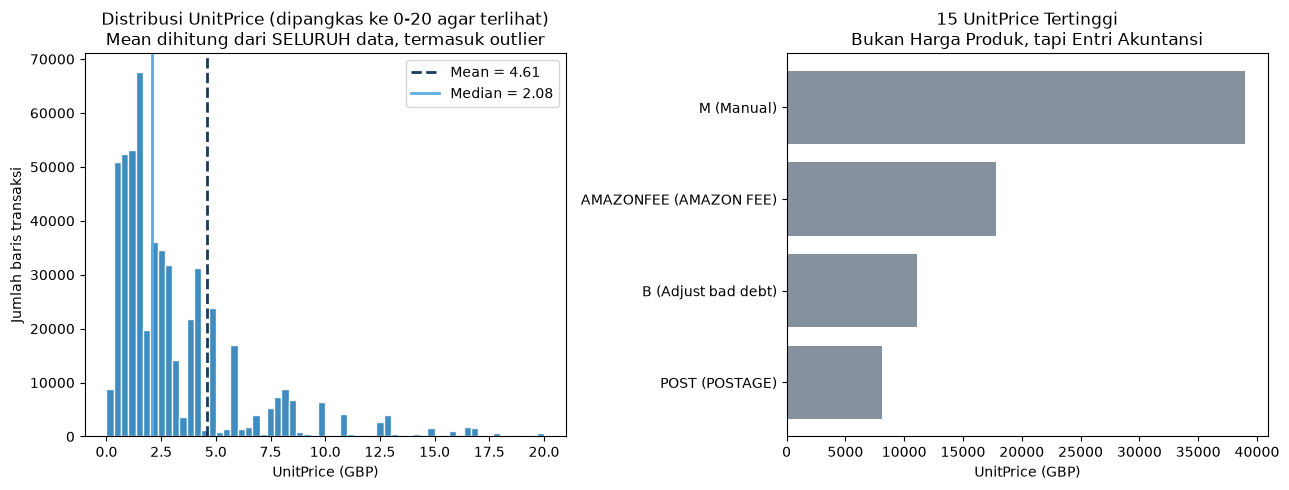

Selisih mean-median: 2.5311
Rasio mean/median: 2.22


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

harga_wajar = df[(df["UnitPrice"] > 0) & (df["UnitPrice"] <= 20)]["UnitPrice"]

axes[0].hist(harga_wajar, bins=60, color="#2980B9", edgecolor="white", alpha=0.9)
axes[0].axvline(mean_up, color="#1B3A5C", linestyle="--", linewidth=2, label=f"Mean = {mean_up:.2f}")
axes[0].axvline(median_up, color="#5DADE2", linestyle="-", linewidth=2, label=f"Median = {median_up:.2f}")
axes[0].set_title("Distribusi UnitPrice (dipangkas ke 0-20 agar terlihat)\nMean dihitung dari SELURUH data, termasuk outlier")
axes[0].set_xlabel("UnitPrice (GBP)")
axes[0].set_ylabel("Jumlah baris transaksi")
axes[0].legend()

top_outlier = df.nlargest(15, "UnitPrice")[["StockCode", "Description", "UnitPrice"]]
axes[1].barh(top_outlier["StockCode"] + " (" + top_outlier["Description"].astype(str).str.slice(0, 18) + ")",
             top_outlier["UnitPrice"], color="#85929E")
axes[1].set_title("15 UnitPrice Tertinggi\nBukan Harga Produk, tapi Entri Akuntansi")
axes[1].set_xlabel("UnitPrice (GBP)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("modul02_mean_vs_median.png", dpi=150, bbox_inches="tight")
plt.show()
print("Selisih mean-median:", round(mean_up - median_up, 4))
print("Rasio mean/median:", round(mean_up / median_up, 2))

## Visualisasi: Proporsi Missing CustomerID (Asset Baru)

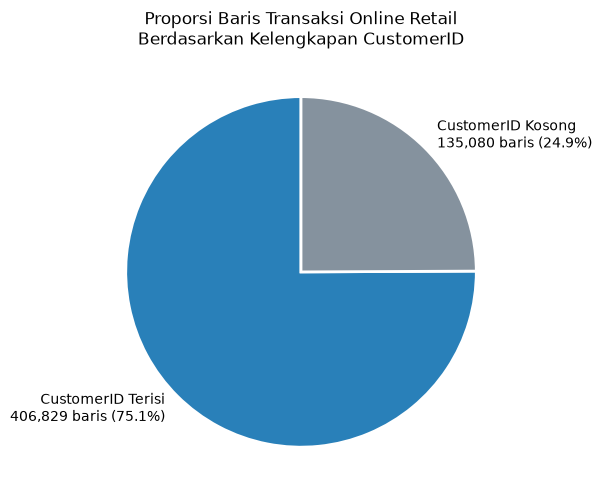

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
labels = ["CustomerID Terisi", "CustomerID Kosong"]
sizes = [len(df) - missing["CustomerID"], missing["CustomerID"]]
colors = ["#2980B9", "#85929E"]
ax.pie(sizes, labels=[f"{l}\n{s:,} baris ({s/len(df)*100:.1f}%)" for l, s in zip(labels, sizes)],
       colors=colors, autopct=None, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Proporsi Baris Transaksi Online Retail\nBerdasarkan Kelengkapan CustomerID")
plt.tight_layout()
plt.savefig("modul02_missing_customerid.png", dpi=150, bbox_inches="tight")
plt.show()